<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_Lags.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 8 — Multivariate window method: room occupancy
- Still the window method, now with covariates: HVAC sensors (temperature, humidity, light, CO2) -> is the room occupied?
- Mostly unoccupied (imbalance); plot the target with CO2 and the story tells itself.
- Lag features from the past few minutes - and DROP lagged occupancy to avoid leakage (20 columns).
- 50/50 unshuffled split, sigmoid head -> ~97% and a mostly-diagonal confusion matrix.
-->


# Multivariate Occupancy Example (Lags/Window Method)
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict if it's a room is occupied as a function of environmental data.

Link: http://archive.ics.uci.edu/ml/datasets/Occupancy+Detection+

Same flow as before, just need to prep our data differently. For now, we ignore the time dimension but we could resample to a regular resolution.

Wow - also a nice example: https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset: UCI room-occupancy detection (Candanedo & Feldheim, 2016), originally from LuisM78's GitHub.
# We use the two real files - 8,143 minutes of training data (Feb 4-10) followed by 9,752 of test (Feb 11-18) -
# stacked in date order into one two-week series. (The 2-day datatest.txt slice was too short to learn from.)
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
df = pd.concat([pd.read_csv(base + "datatraining.txt"), pd.read_csv(base + "datatest2.txt")], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)   # chronological - never shuffle a time series
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 17895 entries, 0 to 17894
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17895 non-null  datetime64[us]
 1   Temperature    17895 non-null  float64       
 2   Humidity       17895 non-null  float64       
 3   Light          17895 non-null  float64       
 4   CO2            17895 non-null  float64       
 5   HumidityRatio  17895 non-null  float64       
 6   Occupancy      17895 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 978.8 KB
None


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [3]:
# count of occupancy
df['Occupancy'].value_counts() # not perfectly balanced, but that's OK

Occupancy
0    14117
1     3778
Name: count, dtype: int64

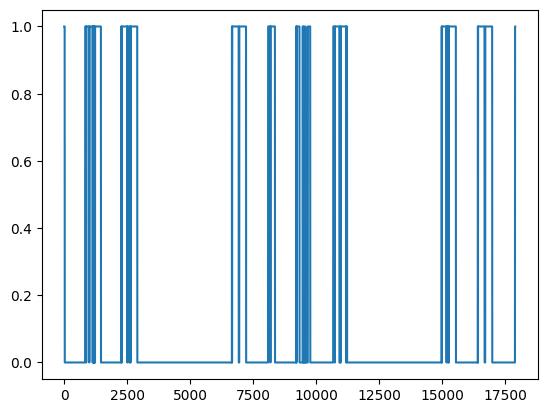

In [4]:
# visualize the data
df['Occupancy'].plot()
plt.show()

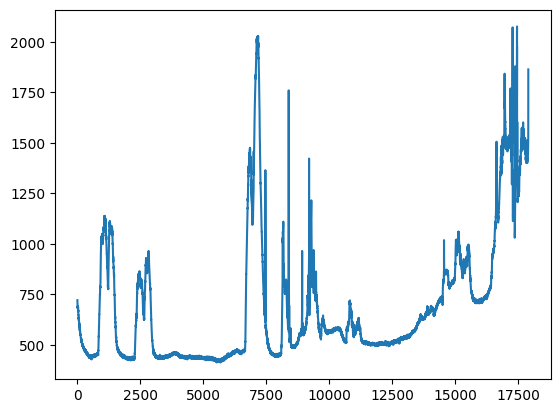

In [5]:
# visualize the data
df['CO2'].plot()
plt.show()

In [6]:
# drop the date column
df.drop(['date'], inplace=True, axis=1)
print(df.shape)
df.head()

(17895, 6)


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


<!-- WINDOW-FN -->
## The window-making function: `series_to_supervised`

Turns a table of time-ordered rows into a table a model can learn from, by lining up shifted copies side by side.

- **`lookback`**: how many **past** rows become input columns (`var(t-lookback)` … `var(t-1)`).
- **`horizon`**: how many rows, **starting now**, become target columns (`var(t)`, `var(t+1)`, …). `horizon=1` means just now.
- **`dropnan`**: drops the edge rows that don't have a full history.

With several columns, **every column gets its own lags**: `var1` … `var5` are the five sensors and `var6` is occupancy. That's why we drop the lagged occupancy columns next (using them would leak the answer).


In [7]:
# link: https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/

# we will probably drop the Y variable before running this

from pandas import DataFrame
from pandas import concat

def series_to_supervised(data, lookback=1, horizon=1, dropnan=True):
	"""
	Frame a time series as a supervised learning dataset.
	Arguments:
		data: Sequence of observations as a list or NumPy array.
		lookback: how many PAST rows become input columns (X) - the lags t-1, t-2, ...
		horizon: how many rows, starting NOW, become target columns (y) - 1 means just t
		dropnan: Boolean whether or not to drop rows with NaN values.
	Returns:
		Pandas DataFrame of series framed for supervised learning.
	"""
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(lookback, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, horizon):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

In [8]:
# now let's prep the data - just processing X
# the SAME look-back as the RNN notebook (n_steps = 10), so the ONLY thing that differs between
# the two notebooks is the SHAPE of X: a flat table here, a 3-D tensor there.
lookback = 10
tmp = series_to_supervised(df, lookback=lookback, horizon=1)

We can do some clean-up here and get rid of the y columns we don't need (unless we want to use prior timesteps!) It's your choice - do you want to use past values of y to make a prediction - or just use the X variables?

In [9]:
print(tmp.info())
tmp.head()

<class 'pandas.DataFrame'>
RangeIndex: 17885 entries, 10 to 17894
Data columns (total 66 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   var1(t-10)  17885 non-null  float64
 1   var2(t-10)  17885 non-null  float64
 2   var3(t-10)  17885 non-null  float64
 3   var4(t-10)  17885 non-null  float64
 4   var5(t-10)  17885 non-null  float64
 5   var6(t-10)  17885 non-null  float64
 6   var1(t-9)   17885 non-null  float64
 7   var2(t-9)   17885 non-null  float64
 8   var3(t-9)   17885 non-null  float64
 9   var4(t-9)   17885 non-null  float64
 10  var5(t-9)   17885 non-null  float64
 11  var6(t-9)   17885 non-null  float64
 12  var1(t-8)   17885 non-null  float64
 13  var2(t-8)   17885 non-null  float64
 14  var3(t-8)   17885 non-null  float64
 15  var4(t-8)   17885 non-null  float64
 16  var5(t-8)   17885 non-null  float64
 17  var6(t-8)   17885 non-null  float64
 18  var1(t-7)   17885 non-null  float64
 19  var2(t-7)   17885 non-null  float64

,var1(t-10),var2(t-10),var3(t-10),var4(t-10),var5(t-10),var6(t-10),var1(t-9),var2(t-9),var3(t-9),var4(t-9),...,var3(t-1),var4(t-1),var5(t-1),var6(t-1),var1(t),var2(t),var3(t),var4(t),var5(t),var6(t)
10,23.18,27.2720,426.0,721.25,0.004793,1.0,23.15,27.2675,429.5,714.00,...,419.0,688.00,0.004745,1.0,23.075,27.150000,419.0,690.25,0.004741,1
11,23.15,27.2675,429.5,714.00,0.004783,1.0,23.15,27.2450,426.0,713.50,...,419.0,690.25,0.004741,1.0,23.100,27.100000,419.0,691.00,0.004739,1
12,23.15,27.2450,426.0,713.50,0.004779,1.0,23.15,27.2000,426.0,708.25,...,419.0,691.00,0.004739,1.0,23.100,27.166667,419.0,683.50,0.004751,1
13,23.15,27.2000,426.0,708.25,0.004772,1.0,23.10,27.2000,426.0,704.50,...,419.0,683.50,0.004751,1.0,23.050,27.150000,419.0,687.50,0.004734,1
14,23.10,27.2000,426.0,704.50,0.004757,1.0,23.10,27.2000,419.0,701.00,...,419.0,687.50,0.004734,1.0,23.000,27.125000,419.0,686.00,0.004715,1


In [10]:
# here are X and y
y = tmp['var6(t)']
X = tmp.drop(['var6(t)'], axis=1)
print(X.shape, y.shape)

(17885, 65) (17885,)


In [11]:
# delete the past occupancy columns, so the model works from the SENSORS ONLY.
# this is the window-method equivalent of the RNN notebook's sequences[i:end_ix, :-1],
# which drops the target column from X for exactly the same reason.
for k in range(1, lookback + 1):
    del X[f'var6(t-{k})']
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 17885 entries, 10 to 17894
Data columns (total 55 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   var1(t-10)  17885 non-null  float64
 1   var2(t-10)  17885 non-null  float64
 2   var3(t-10)  17885 non-null  float64
 3   var4(t-10)  17885 non-null  float64
 4   var5(t-10)  17885 non-null  float64
 5   var1(t-9)   17885 non-null  float64
 6   var2(t-9)   17885 non-null  float64
 7   var3(t-9)   17885 non-null  float64
 8   var4(t-9)   17885 non-null  float64
 9   var5(t-9)   17885 non-null  float64
 10  var1(t-8)   17885 non-null  float64
 11  var2(t-8)   17885 non-null  float64
 12  var3(t-8)   17885 non-null  float64
 13  var4(t-8)   17885 non-null  float64
 14  var5(t-8)   17885 non-null  float64
 15  var1(t-7)   17885 non-null  float64
 16  var2(t-7)   17885 non-null  float64
 17  var3(t-7)   17885 non-null  float64
 18  var4(t-7)   17885 non-null  float64
 19  var5(t-7)   17885 non-null  float64

In [12]:
# take a peak at what it did
print("X shape:", X.shape, " y shape:", y.shape)
print()
n_sensors = len(df.columns) - 1
print(f"{lookback} minutes x {n_sensors} sensors = {lookback * n_sensors} columns, flattened into ONE ROW per sample.")
print("The RNN notebook keeps the same numbers as", (X.shape[0], lookback, n_sensors), "- a 3-D tensor, one row per minute.")
print()
print("Same data, same look-back. The only thing that changes is the SHAPE - and that is the whole point of Module 4.")

X shape: (17885, 55)  y shape: (17885,)

10 minutes x 5 sensors = 50 columns, flattened into ONE ROW per sample.
The RNN notebook keeps the same numbers as (17885, 10, 5) - a 3-D tensor, one row per minute.

Same data, same look-back. The only thing that changes is the SHAPE - and that is the whole point of Module 4.


In [13]:
# split the data into train and test partitions
# we will use 50% of the data for train, and 50% for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [14]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

# verify that this all adds up!

(17885, 55) (8942, 55) (8943, 55)
(17885,) (8942,) (8943,)


## One helper to score every model

Every model below gets the same treatment, so they are comparable: **train and test**, the F1 for each, the test
confusion matrix, and two pictures.

The important choice here is that we plot **`model.predict()` directly - the probability - and never the rounded
class**. Rounding to 0/1 throws away the only interesting part, which is *how sure the model was*. A model that
says 0.51 and a model that says 0.99 both round to "occupied", and you want to be able to tell them apart.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

scores = {}

def show_results(name, model):
    """Train and test for a classifier - and we plot the PROBABILITY the model reports, never the rounded class.
    Rounding throws away the only interesting part: how SURE the model was.

    The plot is P(occupied) over time, with the true occupancy shaded behind it, the 0.5 threshold dashed,
    and a black dot on every window the model got wrong."""
    p_tr = model.predict(X_train, verbose=0).ravel()
    p_te = model.predict(X_test,  verbose=0).ravel()
    f1_tr = f1_score(y_train, (p_tr >= 0.5).astype(int), average="weighted")
    f1_te = f1_score(y_test,  (p_te >= 0.5).astype(int), average="weighted")
    scores[name] = f1_te
    print(f"{name}:  train F1 = {f1_tr:.3f}   test F1 = {f1_te:.3f}   (gap {f1_te - f1_tr:+.3f})")
    print("\nconfusion matrix (test):")
    print(confusion_matrix(y_test, (p_te >= 0.5).astype(int)))
    print(classification_report(y_test, (p_te >= 0.5).astype(int), digits=3))

    SLICE = 1500                    # how much of the TIMELINE to draw - the whole test set at once is a barcode
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
    for r, (split, y_true, p) in enumerate([("train", y_train, p_tr), ("test", y_test, p_te)]):
        start = int(np.argmax(np.abs(np.diff(y_true)) > 0))          # start at the first change of state
        sl = slice(start, start + SLICE)
        t = np.arange(len(y_true))[sl]
        ax[r].fill_between(t, 0, y_true[sl], step="mid", color="#C8E6C9", label="TRUTH: room was occupied (shaded)")
        ax[r].plot(t, p[sl], color="#C62828", lw=1.0, label="MODEL: P(occupied) (red line)")
        ax[r].axhline(0.5, color="#616161", ls="--", lw=0.8)
        ax[r].set_ylim(-0.05, 1.05); ax[r].set_ylabel("P(occupied)")
        ax[r].set_title(f"{name} - {split} set (zoomed in)")
        ax[r].legend(loc="center left", fontsize=8, framealpha=0.9)
        wrong = (p[sl] >= 0.5) != (y_true[sl] >= 0.5)
        ax[r].scatter(t[wrong], p[sl][wrong], s=9, color="black", zorder=5,
                         label="the model got these wrong")
    ax[1].set_xlabel("time step (minute)")
    plt.tight_layout(); plt.show()

In [16]:
def metrics_table(y_true_cls, y_pred_cls, labels=("empty", "occupied")):
    """Every intermediate number behind accuracy / macro F1 / weighted F1 - shown, not asserted."""
    y_true_cls = np.asarray(y_true_cls).astype(int).ravel()
    y_pred_cls = np.asarray(y_pred_cls).astype(int).ravel()
    rows = []
    for k, cname in enumerate(labels):
        tp = int(((y_pred_cls == k) & (y_true_cls == k)).sum())
        fp = int(((y_pred_cls == k) & (y_true_cls != k)).sum())
        fn = int(((y_pred_cls != k) & (y_true_cls == k)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        n_c  = int((y_true_cls == k).sum())
        rows.append({"class": cname, "TP": tp, "FP": fp, "FN": fn,
                     "precision": round(prec, 4), "recall": round(rec, 4), "F1": round(f1, 4),
                     "support n_c": n_c, "n_c x F1": round(n_c * f1, 1)})
    t = pd.DataFrame(rows).set_index("class")
    N = int(t["support n_c"].sum()); correct = int((y_pred_cls == y_true_cls).sum())
    macro = t["F1"].mean(); weighted = t["n_c x F1"].sum() / N
    display(t)
    print(f"accuracy    = correct / all     = {correct:,} / {N:,} = {correct/N:.4f}")
    print(f"macro F1    = (F1_0 + F1_1) / 2 = ({t['F1'].iloc[0]:.4f} + {t['F1'].iloc[1]:.4f}) / 2 = {macro:.4f}")
    print(f"weighted F1 = sum(n_c x F1) / N = {t['n_c x F1'].sum():,.1f} / {N:,} = {weighted:.4f}")
    return {"accuracy": correct/N, "macro F1": macro, "weighted F1": weighted}

> **Careful with the word "window".** The x-axis below is the **calendar** - we draw 1,500 consecutive minutes so
> the chart is readable instead of a 9,000-minute barcode. That is a completely different thing from the model's
> **look-back window**, which is only a handful of minutes and is what each single dot on that line was computed
> from. One point on the red line = one sample = one look-back window.

### Reading the classification report

Three numbers get reported and they answer three different questions. Everything comes out of the confusion matrix:

|  | predicted empty | predicted occupied |
| :-- | :-: | :-: |
| **was empty** | TN | FP |
| **was occupied** | FN | TP |

**Per class**, "precision" is how often it was right when it said so, and "recall" is how much of the class it
caught. $F_1$ is their harmonic mean, which punishes a model that buys one by giving up the other:

$$
\text{precision} = \frac{TP}{TP + FP}, \qquad
\text{recall} = \frac{TP}{TP + FN}, \qquad
F_1 = 2\,\frac{\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}}
$$

**Accuracy** ignores classes entirely - it is just the share of rows on the diagonal:

$$
\text{accuracy} = \frac{TP + TN}{\text{all windows}}
$$

**The two averages** differ only in what they weight by. Let $n_c$ be the **support** of class $c$ - how many test
windows actually belong to it:

$$
\text{macro } F_1 = \frac{1}{C}\sum_{c} F_1^{(c)}
\qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c\,F_1^{(c)}}{\sum_c n_c}
$$

**Macro treats the two classes as equally important.** **Weighted treats every window as equally important**, so
the big class dominates it.

#### Worked, with this notebook's LSTM

| class | precision | recall | $F_1$ | support |
| :-- | --: | --: | --: | --: |
| empty | 0.972 | 0.968 | 0.970 | 7,108 |
| occupied | 0.878 | 0.892 | 0.885 | 1,835 |

$$
\text{macro } F_1 = \frac{0.970 + 0.885}{2} = 0.9275 \approx \mathbf{0.928}
$$

$$
\text{weighted } F_1 = \frac{0.970(7{,}108) + 0.885(1{,}835)}{8{,}943} = \frac{8{,}519}{8{,}943} = \mathbf{0.953}
$$

Weighted comes out higher because the class the model is better at is also the class that is four times bigger.

#### Why we bother reporting all three

Put the majority-class baseline - the one that never says "occupied" - next to the LSTM:

| model | accuracy | weighted $F_1$ | macro $F_1$ |
| :-- | --: | --: | --: |
| always guess "empty" | 0.795 | 0.704 | **0.443** |
| LSTM(30) | 0.952 | 0.953 | **0.928** |

**Accuracy says the useless model is 80% right.** Weighted $F_1$ is suspicious of it. **Macro $F_1$ exposes it**,
because the occupied class scores $F_1 = 0$ and macro refuses to let the big class hide that.

Rule of thumb: on imbalanced data, quote **macro** when both classes matter to you - and for a room-occupancy
sensor, detecting the *occupied* minutes is the entire point.

In [17]:
# if we wanted to, we could do some scaling/normalization here, would not hurt!
# link: https://datascience.stackexchange.com/questions/12321/whats-the-difference-between-fit-and-fit-transform-in-scikit-learn-models

# do we need to fit this twice?!

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)

array([[-0.05923375, -0.21118958, -0.61339997, ..., -0.61167534,
        -0.13844963, -0.34271446],
       [-0.05923375, -0.25405894, -0.61339997, ..., -0.61167534,
        -0.12582974, -0.40095313],
       [-0.05923375, -0.30251996, -0.61339997, ..., -0.61167534,
        -0.1340601 , -0.39194774],
       ...,
       [ 0.18269489,  0.16345139, -0.5516663 , ...,  1.56953398,
         3.01158462,  0.39325504],
       [ 0.13229309,  0.15413196, -0.54137735, ...,  1.54506941,
         3.37536666,  0.44424666],
       [ 0.13229309,  0.14993822, -0.56195524, ...,  1.49485267,
         4.13914434,  0.49354025]], shape=(8943, 55))

# DNN one layer model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,711 (6.68 KB)

 Trainable params: 1,711 (6.68 KB)

 Non-trainable params: 0 (0.00 B)

...

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9777 - loss: 0.1760

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9752 - loss: 0.1711

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9754 - loss: 0.1799 - val_acc: 0.9117 - val_loss: 0.7631


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 4.


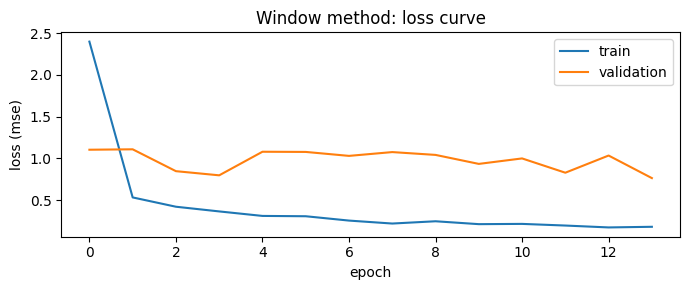

stopped after 14 epochs; best validation loss 0.763


In [18]:
# now let's build a model

# define model
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)


# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Window method: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

window method (dense net on the lag table):  train F1 = 0.970   test F1 = 0.943   (gap -0.027)

confusion matrix (test):
[[6909  199]
 [ 309 1526]]
              precision    recall  f1-score   support

           0      0.957     0.972     0.965      7108
           1      0.885     0.832     0.857      1835

    accuracy                          0.943      8943
   macro avg      0.921     0.902     0.911      8943
weighted avg      0.942     0.943     0.943      8943



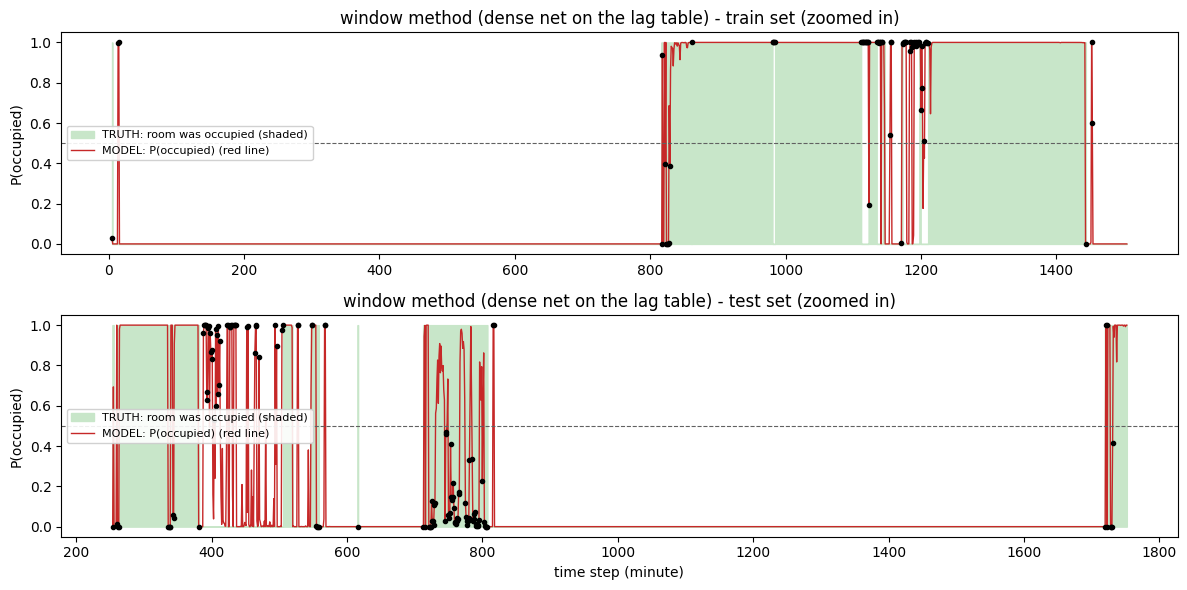

In [19]:
show_results("window method (dense net on the lag table)", model)

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [20]:
from keras.models import load_model

model.save('Multivariate_Occupancy_Lags.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Multivariate_Occupancy_Lags.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,135 (20.06 KB)

 Trainable params: 1,711 (6.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,424 (13.38 KB)

Think about what a baseline model would be... is it possible to predict occupancy without previous Y data (just use X?) To do this, you would just need to delete some of the variables in tmp before splitting, then re-run the model.

### Balanced vs imbalanced: why one score is not enough

The room is empty **78%** of the time, so the classes are badly imbalanced. That single fact is what makes
`accuracy` untrustworthy here, and the table below shows exactly where the three summary numbers come from so you
can see it rather than take my word for it.

$$\text{macro } F_1 = \frac{1}{C}\sum_c F_1^{(c)} \qquad\qquad
\text{weighted } F_1 = \frac{\sum_c n_c F_1^{(c)}}{\sum_c n_c}$$

Same per-class $F_1$ values, different weights. **Macro** gives the two classes equal say. **Weighted** gives every
*window* equal say, so the big class runs the show.

Run it on a real model and on the do-nothing baseline, and watch which number notices the difference.

In [21]:
print("=" * 62)
print("A REAL MODEL")
print("=" * 62)
m_model = metrics_table(y_test, (model.predict(X_test, verbose=0).ravel() >= 0.5))

print()
print("=" * 62)
print("THE DO-NOTHING BASELINE: always guess 'empty'")
print("=" * 62)
m_dumb = metrics_table(y_test, np.zeros(len(y_test)))

print()
display(pd.DataFrame({"a real model": m_model, "always guess empty": m_dumb}).round(3))
print("Accuracy barely drops. Weighted F1 gets suspicious. MACRO F1 collapses -")
print("because the 'occupied' class scores F1 = 0 and macro refuses to let the big class hide it.")
print("\nOn imbalanced data, quote MACRO when both classes matter - and here, catching the")
print("occupied minutes is the entire reason the sensor exists.")

A REAL MODEL


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,6909,309,199,0.9572,0.9720,0.9645,7108,6856.0
occupied,1526,199,309,0.8846,0.8316,0.8573,1835,1573.2


accuracy    = correct / all     = 8,435 / 8,943 = 0.9432
macro F1    = (F1_0 + F1_1) / 2 = (0.9645 + 0.8573) / 2 = 0.9109
weighted F1 = sum(n_c x F1) / N = 8,429.2 / 8,943 = 0.9425

THE DO-NOTHING BASELINE: always guess 'empty'


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,7108,1835,0,0.7948,1.0,0.8857,7108,6295.4
occupied,0,0,1835,0.0000,0.0,0.0000,1835,0.0


accuracy    = correct / all     = 7,108 / 8,943 = 0.7948
macro F1    = (F1_0 + F1_1) / 2 = (0.8857 + 0.0000) / 2 = 0.4429
weighted F1 = sum(n_c x F1) / N = 6,295.4 / 8,943 = 0.7039



,a real model,always guess empty
accuracy,0.943,0.795
macro F1,0.911,0.443
weighted F1,0.943,0.704


Accuracy barely drops. Weighted F1 gets suspicious. MACRO F1 collapses -
because the 'occupied' class scores F1 = 0 and macro refuses to let the big class hide it.

On imbalanced data, quote MACRO when both classes matter - and here, catching the
occupied minutes is the entire reason the sensor exists.
